In [1]:
import pandas as pd
df = pd.read_excel('../data/DGA_train.xlsx')
df.shape


(584, 6)

In [2]:
df.columns.tolist()

['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2', 'Fault class']

In [3]:
df.head(10)

,H2,CH4,C2H6,C2H4,C2H2,Fault class
0,1076.00,95.000,4.000,71.000,231.0000,1
1,407.00,28.000,15.000,21.000,0.0001,1
2,2240.00,560.000,380.000,450.000,940.0000,1
3,92600.00,10200.000,1.000,2.000,0.0001,1
4,2587.20,112.250,4.704,1.400,0.0001,1
5,195.90,14.500,11.600,2.400,0.0001,1
6,180.85,0.574,0.234,0.188,0.0001,1
7,4480.00,560.000,380.000,403.000,896.0000,1
8,1651.00,90.000,33.000,45.000,2.0000,1
9,980.00,73.000,58.000,12.000,0.0001,1


In [4]:
df.isnull().sum()

H2             0
CH4            0
C2H6           0
C2H4           0
C2H2           0
Fault class    0
dtype: int64

In [5]:
df['Fault class'].value_counts()


Fault class
3    134
4     96
6     89
0     85
2     76
1     59
5     45
Name: count, dtype: int64

In [6]:
import sys
sys.path.append('../src/classical')
from key_gas import key_gas

In [7]:
key_gas(100, 20, 5, 10, 2)

'PD'

In [8]:
row = df.iloc[0]
key_gas(row['H2'], row['CH4'], row['C2H6'], row['C2H4'], row['C2H2'])

'PD'

In [9]:
from iec_ratios import iec_ratios

# a clear high-energy arcing case (lots of acetylene):
iec_ratios(100, 70, 20, 100, 200)

{'C2H2/C2H4': 2.0, 'CH4/H2': 0.7, 'C2H4/C2H6': 5.0, 'fault': 'D2'}

In [10]:
row = df.iloc[0]
iec_ratios(row['H2'], row['CH4'], row['C2H6'], row['C2H4'], row['C2H2'])

{'C2H2/C2H4': np.float64(3.2535211267605635),
 'CH4/H2': np.float64(0.08828996282527882),
 'C2H4/C2H6': np.float64(17.75),
 'fault': 'No decision (outside IEC table)'}

In [11]:
import matplotlib.pyplot as plt

def duval_percentages(ch4, c2h4, c2h2):
    s = ch4 + c2h4 + c2h2
    if s == 0:
        return None
    return 100*ch4/s, 100*c2h4/s, 100*c2h2/s

def duval_xy(p_ch4, p_c2h4, p_c2h2):
    return p_c2h4 + 0.5*p_ch4, 0.866*p_ch4

def duval_zone(ch4, c2h4, c2h2):
    p = duval_percentages(ch4, c2h4, c2h2)
    if p is None:
        return "No gases (cannot place on triangle)"
    a, b, c = p                 # a = %CH4,  b = %C2H4,  c = %C2H2
    if a >= 98:              return "PD"
    if c >= 13 and b <= 23:  return "D1"
    if c >= 13 and b <= 40:  return "D2"
    if c < 4 and b < 20:     return "T1"
    if c < 4 and b < 50:     return "T2"
    if c < 15 and b >= 50:   return "T3"
    return "DT"

def plot_duval(ch4, c2h4, c2h2):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 100, 50, 0], [0, 0, 86.6, 0], 'k-', lw=1.5)
    ax.text(-2, -4, '100% C2H2', ha='right', fontsize=9)
    ax.text(102, -4, '100% C2H4', ha='left', fontsize=9)
    ax.text(50, 89, '100% CH4', ha='center', fontsize=9)
    p = duval_percentages(ch4, c2h4, c2h2)
    zone = duval_zone(ch4, c2h4, c2h2)
    if p:
        x, y = duval_xy(*p)
        ax.plot(x, y, 'ro', markersize=11)
        ax.annotate(f'  {zone}', (x, y), color='red', fontweight='bold', fontsize=12)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title('Duval Triangle 1')
    plt.show()
    return zone

In [12]:
duval_zone(0, 100, 0)      # pure ethylene -> 'T3'

'T3'

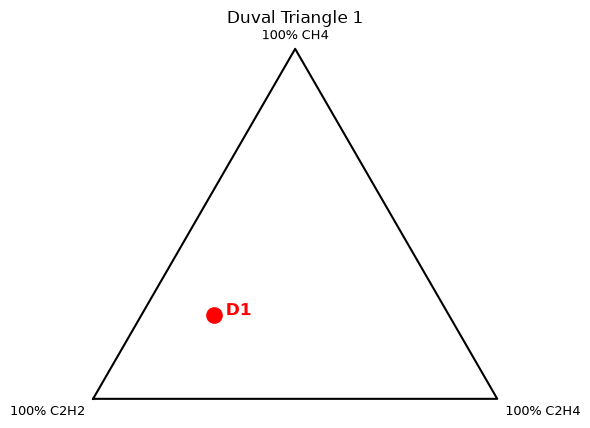

'D1'

In [13]:
row = df.iloc[0]
plot_duval(row['CH4'], row['C2H4'], row['C2H2'])     # shows the triangle, returns 'D1'

In [14]:
print(open('../src/classical/duval.py').read())

# duval.py
# The Duval Triangle 1 method: turn three gases into a point and read its fault zone.
import matplotlib.pyplot as plt

def duval_percentages(ch4, c2h4, c2h2):
    """Turn the three gases into percentages of their own total."""
    s = ch4 + c2h4 + c2h2
    if s == 0:
        return None
    return 100*ch4/s, 100*c2h4/s, 100*c2h2/s

def duval_xy(p_ch4, p_c2h4, p_c2h2):
    """Turn the three percentages into an (x, y) point on the triangle."""
    return p_c2h4 + 0.5*p_ch4, 0.866*p_ch4

def duval_zone(ch4, c2h4, c2h2):
    """Return the Duval Triangle 1 fault zone for the three gases."""
    p = duval_percentages(ch4, c2h4, c2h2)
    if p is None:
        return "No gases (cannot place on triangle)"
    a, b, c = p                 # a = %CH4,  b = %C2H4,  c = %C2H2
    if a >= 98:              return "PD"
    if c >= 13 and b <= 23:  return "D1"
    if c >= 13 and b <= 40:  return "D2"
    if c < 4 and b < 20:     return "T1"
    if c < 4 and b < 50:     return "T2"
    if c <

In [15]:
duval_zone(69, 10, 0.0001)     # published example -> should return 'T1'

'T1'

In [16]:
import pandas as pd
iec = pd.read_excel('../data/IEC_TC_10_data.xlsx')

label_name = {0:'Normal', 1:'PD', 2:'D1', 3:'D2', 4:'T1', 5:'T2', 6:'T3'}

matches, nameable = 0, 0
for i in range(len(iec)):
    r = iec.iloc[i]
    predicted = duval_zone(r['CH4'], r['C2H4'], r['C2H2'])
    truth = label_name[int(r['Fault class'])]
    if truth in ('PD', 'D1', 'D2', 'T1', 'T2', 'T3'):   # cases Duval can name
        nameable += 1
        if predicted == truth:
            matches += 1

print("Duval matched the published diagnosis on", matches, "of", nameable, "cases")

Duval matched the published diagnosis on 28 of 34 cases
